# EDA 16.1: Target Distribution Analysis

This notebook analyzes the target variable distribution for Revenue, inspects skewness and extreme values, and evaluates whether a `log1p(Revenue)` transform may be useful for modeling.

## 1. Setup and File Discovery

Locate `sales.csv` and optional fallback sources under the current working directory. Missing files generate warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("default")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
FILES = ["sales.csv", "orders.csv", "order_items.csv", "payments.csv"]

def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "", str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob("*.csv"):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame(
    [
        {"file": name, "found": path is not None, "path": str(path) if path else None}
        for name, path in selected_paths.items()
    ]
)
display(file_status)

,file,found,path
0,sales.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
1,orders.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
2,order_items.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
3,payments.csv,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...


## 2. Load or Reconstruct Daily Revenue

Load `sales.csv` when available. If it is missing or unusable, try reconstructing daily Revenue from `orders.csv` plus `order_items.csv`, or from `payments.csv` as a fallback proxy.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as exc:
        warnings.warn(f"Failed to load {path}: {exc}")
        return None

sales = load_csv_safe(selected_paths["sales.csv"])
orders = load_csv_safe(selected_paths["orders.csv"])
order_items = load_csv_safe(selected_paths["order_items.csv"])
payments = load_csv_safe(selected_paths["payments.csv"])

schema_rows = []
for name, df in {
    "sales": sales,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
}.items():
    schema_rows.append(
        {
            "dataset": name,
            "loaded": df is not None,
            "rows": None if df is None else len(df),
            "columns": None if df is None else ", ".join(map(str, df.columns[:20])),
        }
    )
display(pd.DataFrame(schema_rows))

def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

sales_cols = {}
if sales is not None:
    sales_cols = {
        "date": find_column(sales.columns, ["date", "sales_date", "order_date"], contains=True),
        "revenue": find_column(sales.columns, ["revenue", "sales_amount", "total_revenue", "amount"], contains=True),
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        "order_id": find_column(orders.columns, ["order_id"]),
        "order_date": find_column(orders.columns, ["order_date", "date"], contains=True),
        "order_status": find_column(orders.columns, ["order_status", "status"], contains=True),
    }

item_cols = {}
if order_items is not None:
    item_cols = {
        "order_id": find_column(order_items.columns, ["order_id"]),
        "quantity": find_column(order_items.columns, ["quantity", "qty", "units"], contains=True),
        "unit_price": find_column(order_items.columns, ["unit_price", "price", "selling_price"], contains=True),
        "discount_amount": find_column(order_items.columns, ["discount_amount", "discount"], contains=True),
        "item_revenue": find_column(order_items.columns, ["item_total", "line_total", "revenue", "sales_amount", "net_sales"], contains=True),
    }

payment_cols = {}
if payments is not None:
    payment_cols = {
        "order_id": find_column(payments.columns, ["order_id"]),
        "payment_value": find_column(payments.columns, ["payment_value", "amount", "payment_amount", "value"], contains=True),
    }

identified = pd.DataFrame(
    {
        "sales": pd.Series(sales_cols),
        "orders": pd.Series(orders_cols),
        "order_items": pd.Series(item_cols),
        "payments": pd.Series(payment_cols),
    }
)
display(identified)

,dataset,loaded,rows,columns
0,sales,True,3833,"Date, Revenue, COGS"
1,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
2,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
3,payments,True,646945,"order_id, payment_method, payment_value, insta..."


,sales,orders,order_items,payments
date,Date,NaN,NaN,NaN
discount_amount,NaN,NaN,discount_amount,NaN
item_revenue,NaN,NaN,None,NaN
order_date,NaN,order_date,NaN,NaN
order_id,NaN,order_id,order_id,order_id
order_status,NaN,order_status,NaN,NaN
payment_value,NaN,NaN,NaN,payment_value
quantity,NaN,NaN,quantity,NaN
revenue,Revenue,NaN,NaN,NaN
unit_price,NaN,NaN,unit_price,NaN


## 3. Revenue Data Quality Checks

Prepare a daily Revenue table, validate dates and values, and report how Revenue was sourced.

In [3]:
revenue_source = None
daily_revenue = pd.DataFrame(columns=["date", "Revenue"])

if sales is not None and sales_cols.get("date") and sales_cols.get("revenue"):
    sales_daily = sales.copy()
    sales_daily["date"] = pd.to_datetime(sales_daily[sales_cols["date"]], errors="coerce")
    sales_daily["Revenue"] = pd.to_numeric(sales_daily[sales_cols["revenue"]], errors="coerce")
    daily_revenue = (
        sales_daily.dropna(subset=["date"])
        .groupby("date", as_index=False)["Revenue"]
        .sum()
        .sort_values("date")
    )
    revenue_source = "sales.csv"

elif (
    orders is not None
    and order_items is not None
    and orders_cols.get("order_id")
    and orders_cols.get("order_date")
    and item_cols.get("order_id")
):
    orders_tmp = orders.copy()
    orders_tmp["order_id_std"] = orders_tmp[orders_cols["order_id"]]
    orders_tmp["order_date_std"] = pd.to_datetime(orders_tmp[orders_cols["order_date"]], errors="coerce")
    if orders_cols.get("order_status"):
        orders_tmp["order_status_std"] = orders_tmp[orders_cols["order_status"]].astype(str).str.strip().str.lower()
    else:
        orders_tmp["order_status_std"] = pd.NA

    items_tmp = order_items.copy()
    items_tmp["order_id_std"] = items_tmp[item_cols["order_id"]]
    qty = pd.to_numeric(items_tmp[item_cols["quantity"]], errors="coerce") if item_cols.get("quantity") else np.nan
    price = pd.to_numeric(items_tmp[item_cols["unit_price"]], errors="coerce") if item_cols.get("unit_price") else np.nan
    discount = pd.to_numeric(items_tmp[item_cols["discount_amount"]], errors="coerce").fillna(0) if item_cols.get("discount_amount") else 0
    if item_cols.get("item_revenue"):
        items_tmp["item_revenue_std"] = pd.to_numeric(items_tmp[item_cols["item_revenue"]], errors="coerce")
    else:
        items_tmp["item_revenue_std"] = qty * price

    order_rev = items_tmp.groupby("order_id_std", as_index=False)["item_revenue_std"].sum()
    order_rev = order_rev.merge(
        orders_tmp[["order_id_std", "order_date_std", "order_status_std"]],
        on="order_id_std",
        how="left",
    )
    cancelled_terms = ("cancel", "refund", "failed", "void")
    mask_cancel = order_rev["order_status_std"].astype(str).str.contains("|".join(cancelled_terms), case=False, na=False)
    order_rev["is_status_flagged"] = mask_cancel
    daily_revenue = (
        order_rev.dropna(subset=["order_date_std"])
        .groupby("order_date_std", as_index=False)["item_revenue_std"]
        .sum()
        .rename(columns={"order_date_std": "date", "item_revenue_std": "Revenue"})
        .sort_values("date")
    )
    revenue_source = "orders.csv + order_items.csv"

elif (
    payments is not None
    and orders is not None
    and payment_cols.get("order_id")
    and payment_cols.get("payment_value")
    and orders_cols.get("order_id")
    and orders_cols.get("order_date")
):
    pay_tmp = payments.copy()
    pay_tmp["order_id_std"] = pay_tmp[payment_cols["order_id"]]
    pay_tmp["payment_value_std"] = pd.to_numeric(pay_tmp[payment_cols["payment_value"]], errors="coerce")
    pay_agg = pay_tmp.groupby("order_id_std", as_index=False)["payment_value_std"].sum()
    orders_tmp = orders.copy()
    orders_tmp["order_id_std"] = orders_tmp[orders_cols["order_id"]]
    orders_tmp["order_date_std"] = pd.to_datetime(orders_tmp[orders_cols["order_date"]], errors="coerce")
    daily_revenue = (
        pay_agg.merge(orders_tmp[["order_id_std", "order_date_std"]], on="order_id_std", how="left")
        .dropna(subset=["order_date_std"])
        .groupby("order_date_std", as_index=False)["payment_value_std"]
        .sum()
        .rename(columns={"order_date_std": "date", "payment_value_std": "Revenue"})
        .sort_values("date")
    )
    revenue_source = "payments.csv + orders.csv"

else:
    warnings.warn("Revenue could not be identified or reconstructed from the available files.")

if not daily_revenue.empty:
    daily_revenue = daily_revenue.sort_values("date").reset_index(drop=True)
    all_days = pd.date_range(daily_revenue["date"].min(), daily_revenue["date"].max(), freq="D")
    duplicate_dates = int(daily_revenue["date"].duplicated().sum())
    missing_dates = int(len(all_days.difference(daily_revenue["date"])))
    quality = pd.DataFrame(
        [
            {
                "revenue_source": revenue_source,
                "date_start": daily_revenue["date"].min(),
                "date_end": daily_revenue["date"].max(),
                "number_of_days": len(daily_revenue),
                "missing_dates": missing_dates,
                "missing_revenue_values": int(daily_revenue["Revenue"].isna().sum()),
                "zero_revenue_days": int(daily_revenue["Revenue"].eq(0).sum()),
                "negative_revenue_days": int(daily_revenue["Revenue"].lt(0).sum()),
                "duplicated_dates": duplicate_dates,
            }
        ]
    )
    display(quality)
    display(daily_revenue.head(10))
else:
    print("Daily Revenue table is empty.")

,revenue_source,date_start,date_end,number_of_days,missing_dates,missing_revenue_values,zero_revenue_days,negative_revenue_days,duplicated_dates
0,sales.csv,2012-07-04,2022-12-31,3833,0,0,0,0,0


,date,Revenue
0,2012-07-04,"5,123,547.9400"
1,2012-07-05,"2,751,773.4500"
2,2012-07-06,"3,054,029.4200"
3,2012-07-07,"2,667,930.9400"
4,2012-07-08,"2,360,851.9000"
5,2012-07-09,"3,548,386.4600"
6,2012-07-10,"5,234,938.6200"
7,2012-07-11,"5,582,884.7800"
8,2012-07-12,"5,734,632.0200"
9,2012-07-13,"5,309,511.7100"


## 4. Revenue Summary Statistics

Compute shape, spread, tail, and skewness statistics for the daily Revenue target.

In [4]:
summary_table = pd.DataFrame()

if not daily_revenue.empty:
    rev = daily_revenue["Revenue"].dropna()
    summary_table = pd.DataFrame(
        [
            {
                "count": rev.count(),
                "mean": rev.mean(),
                "median": rev.median(),
                "std": rev.std(),
                "min": rev.min(),
                "p1": rev.quantile(0.01),
                "p5": rev.quantile(0.05),
                "p10": rev.quantile(0.10),
                "p25": rev.quantile(0.25),
                "p75": rev.quantile(0.75),
                "p90": rev.quantile(0.90),
                "p95": rev.quantile(0.95),
                "p99": rev.quantile(0.99),
                "max": rev.max(),
                "skewness": rev.skew(),
                "kurtosis": rev.kurt(),
                "coefficient_of_variation": rev.std() / rev.mean() if rev.mean() != 0 else np.nan,
            }
        ]
    )
    display(summary_table)

    print(f"Mean vs median: {rev.mean():,.2f} vs {rev.median():,.2f}")
    print(f"Top 1% threshold: {rev.quantile(0.99):,.2f}")
    print(f"Bottom 1% threshold: {rev.quantile(0.01):,.2f}")
else:
    print("Revenue summary statistics are unavailable because daily Revenue could not be prepared.")

,count,mean,median,std,min,p1,p5,p10,p25,p75,p90,p95,p99,max,skewness,kurtosis,coefficient_of_variation
0,3833,"4,286,584.0296","3,647,303.9000","2,624,840.1982","279,813.9400","845,078.7520","1,352,929.2340","1,718,265.3480","2,471,088.8200","5,350,877.2000","7,685,788.5300","9,398,759.8720","13,801,990.0536","20,905,271.3500",1.6700,4.0303,0.6123


Mean vs median: 4,286,584.03 vs 3,647,303.90
Top 1% threshold: 13,801,990.05
Bottom 1% threshold: 845,078.75


## 5. Raw Revenue Distribution

Inspect the raw target distribution with both full-range and capped histograms so the body and tail are both visible.

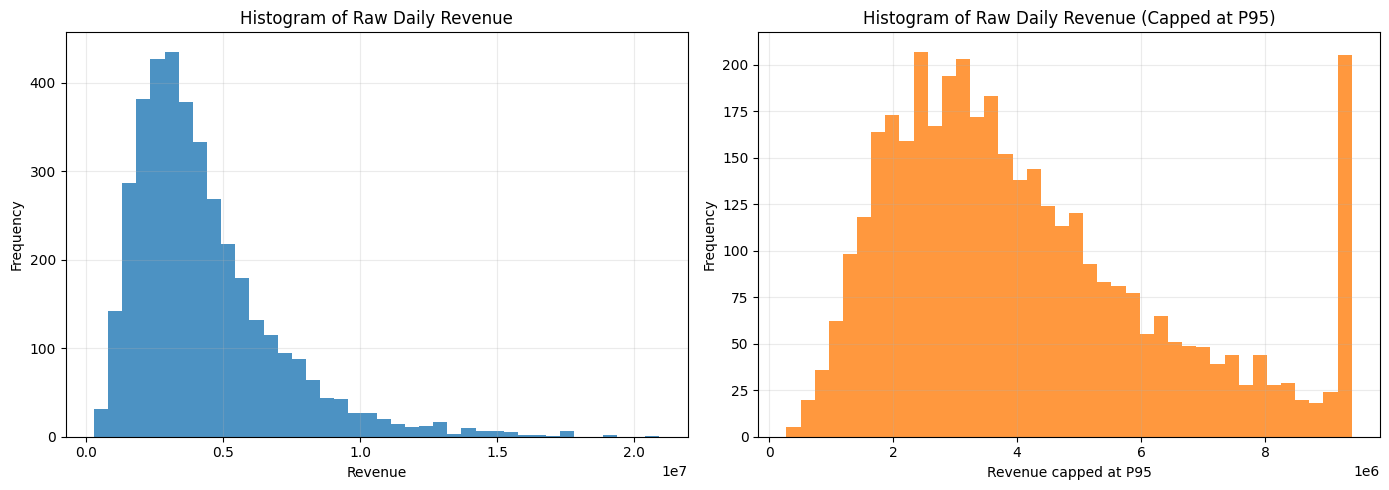

In [5]:
if not daily_revenue.empty:
    rev = daily_revenue["Revenue"].dropna()
    cap95 = rev.quantile(0.95)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(rev, bins=40, color="tab:blue", alpha=0.8)
    axes[0].set_title("Histogram of Raw Daily Revenue")
    axes[0].set_xlabel("Revenue")
    axes[0].set_ylabel("Frequency")
    axes[1].hist(rev.clip(upper=cap95), bins=40, color="tab:orange", alpha=0.8)
    axes[1].set_title("Histogram of Raw Daily Revenue (Capped at P95)")
    axes[1].set_xlabel("Revenue capped at P95")
    axes[1].set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 6. Log Revenue Distribution

Create `log1p(Revenue)` where valid, compare the transformed distribution with raw Revenue, and inspect how skewness changes.

,raw_skewness,log1p_skewness,raw_mean,raw_median,log1p_mean,log1p_median
0,1.6700,-0.1594,"4,286,584.0296","3,647,303.9000",15.1026,15.1095


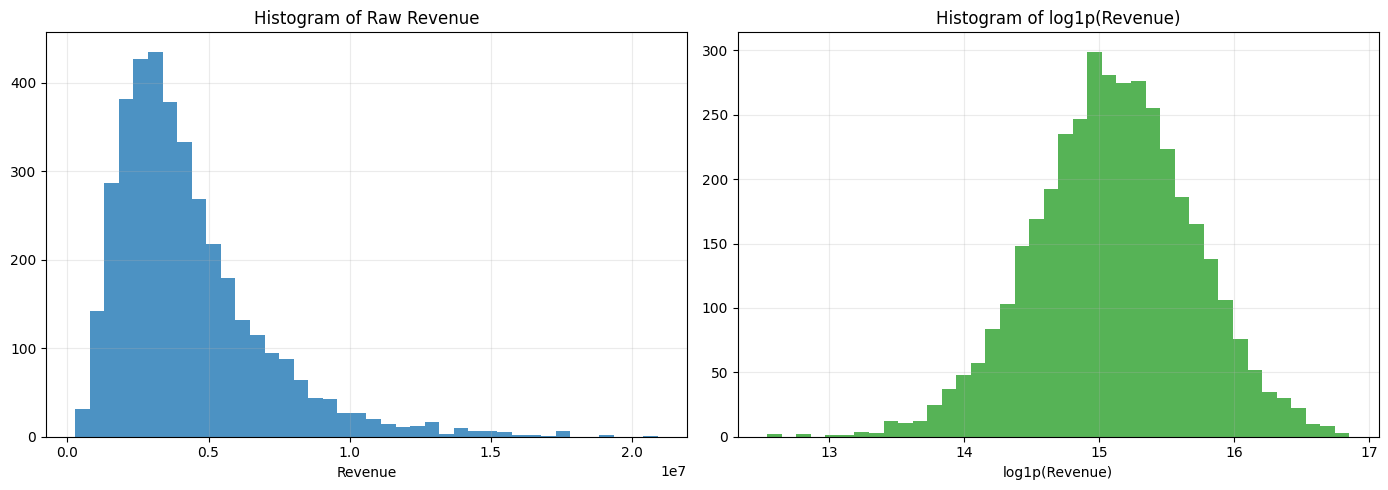

log1p(Revenue) appears to reduce skewness.


In [6]:
log_ready = pd.DataFrame()

if not daily_revenue.empty:
    log_ready = daily_revenue.copy()
    log_ready["log1p_Revenue"] = np.where(log_ready["Revenue"] > -1, np.log1p(log_ready["Revenue"]), np.nan)
    invalid_log = int(log_ready["Revenue"].le(-1).sum())
    if invalid_log:
        print(f"log1p is invalid for {invalid_log} rows because Revenue <= -1.")

    compare = pd.DataFrame(
        [
            {
                "raw_skewness": log_ready["Revenue"].dropna().skew(),
                "log1p_skewness": log_ready["log1p_Revenue"].dropna().skew(),
                "raw_mean": log_ready["Revenue"].mean(),
                "raw_median": log_ready["Revenue"].median(),
                "log1p_mean": log_ready["log1p_Revenue"].mean(),
                "log1p_median": log_ready["log1p_Revenue"].median(),
            }
        ]
    )
    display(compare)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(log_ready["Revenue"].dropna(), bins=40, color="tab:blue", alpha=0.8)
    axes[0].set_title("Histogram of Raw Revenue")
    axes[0].set_xlabel("Revenue")
    axes[1].hist(log_ready["log1p_Revenue"].dropna(), bins=40, color="tab:green", alpha=0.8)
    axes[1].set_title("Histogram of log1p(Revenue)")
    axes[1].set_xlabel("log1p(Revenue)")
    plt.tight_layout()
    plt.show()

    if compare["log1p_skewness"].iloc[0] < compare["raw_skewness"].iloc[0]:
        print("log1p(Revenue) appears to reduce skewness.")
    else:
        print("log1p(Revenue) does not appear to reduce skewness materially in this dataset.")

## 7. Revenue Boxplot by Year

Inspect yearly spread, outliers, and variance on both the raw and log-transformed target scales.

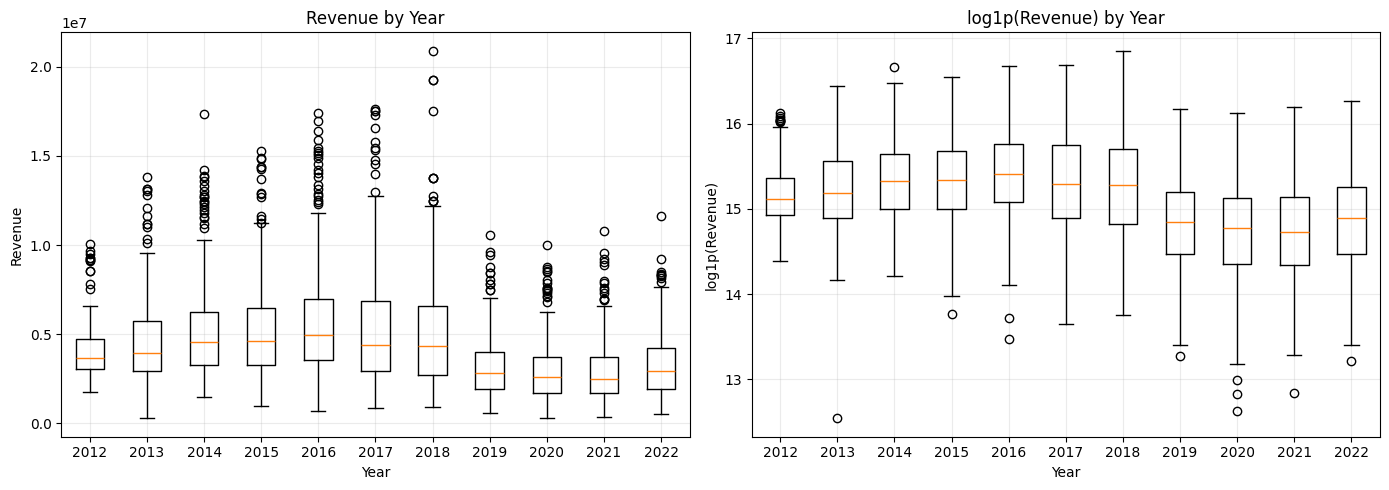

,year,mean_Revenue,median_Revenue,std_Revenue,p95_Revenue,max_Revenue,skewness
0,2012,"4,096,672.6410","3,666,204.8900","1,684,324.3975","8,560,208.9200","10,086,534.1000",1.6308
1,2013,"4,540,190.1843","3,927,167.3400","2,272,146.5648","9,121,695.0620","13,809,349.1800",1.4335
2,2014,"5,128,344.8844","4,538,183.3800","2,677,530.5948","11,151,483.6660","17,347,427.2700",1.4347
3,2015,"5,177,900.8957","4,612,174.4100","2,645,185.8962","10,355,571.5100","15,294,818.2200",1.3124
4,2016,"5,750,384.3649","4,934,152.3750","3,087,505.1338","12,377,179.3375","17,388,183.1900",1.3634
5,2017,"5,236,066.6446","4,375,381.1800","3,075,067.3242","10,862,332.6260","17,639,270.8800",1.5474
6,2018,"5,068,828.6468","4,317,415.3100","3,168,626.2573","10,773,937.9980","20,905,271.3500",1.5363
7,2019,"3,114,524.4973","2,811,323.6300","1,642,733.6475","6,065,294.2940","10,560,540.5500",1.3356
8,2020,"2,881,180.7617","2,596,347.1500","1,637,312.4465","5,949,971.1825","10,020,939.0300",1.3435
9,2021,"2,857,643.3415","2,480,973.6800","1,644,090.6026","5,674,059.9360","10,795,905.3500",1.5069


,month_of_year,average_Revenue,median_Revenue,p95_Revenue
0,1,"2,591,154.6045","2,416,732.6950","5,009,201.5330"
1,2,"3,480,800.7782","3,242,762.8700","6,759,925.4490"
2,3,"4,928,185.4732","4,606,234.9900","9,227,371.7435"
3,4,"6,532,951.8821","5,795,217.0850","12,883,374.5945"
4,5,"6,575,416.3495","6,067,768.6100","12,806,540.5430"
5,6,"6,427,108.6523","5,826,463.1000","12,100,133.6910"
6,7,"4,659,789.3747","4,379,419.2450","8,860,779.7070"
7,8,"4,441,193.4900","3,646,382.1200","9,904,285.9900"
8,9,"3,797,825.6016","3,604,251.2000","6,503,414.6205"
9,10,"3,302,725.2192","3,172,297.0100","6,122,484.1000"


In [7]:
yearly_summary = pd.DataFrame()
monthly_summary = pd.DataFrame()

if not daily_revenue.empty:
    year_df = daily_revenue.copy()
    year_df["year"] = year_df["date"].dt.year
    year_df["month_of_year"] = year_df["date"].dt.month
    year_df["log1p_Revenue"] = np.where(year_df["Revenue"] > -1, np.log1p(year_df["Revenue"]), np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    year_groups = [grp["Revenue"].dropna().values for _, grp in year_df.groupby("year")]
    year_labels = [str(y) for y in sorted(year_df["year"].dropna().unique())]
    axes[0].boxplot(year_groups, tick_labels=year_labels, showfliers=True)
    axes[0].set_title("Revenue by Year")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Revenue")

    log_groups = [grp["log1p_Revenue"].dropna().values for _, grp in year_df.groupby("year")]
    axes[1].boxplot(log_groups, tick_labels=year_labels, showfliers=True)
    axes[1].set_title("log1p(Revenue) by Year")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("log1p(Revenue)")
    plt.tight_layout()
    plt.show()

    yearly_summary = (
        year_df.groupby("year")
        .agg(
            mean_Revenue=("Revenue", "mean"),
            median_Revenue=("Revenue", "median"),
            std_Revenue=("Revenue", "std"),
            p95_Revenue=("Revenue", lambda s: s.quantile(0.95)),
            max_Revenue=("Revenue", "max"),
            skewness=("Revenue", "skew"),
        )
        .reset_index()
    )
    monthly_summary = (
        year_df.groupby("month_of_year")
        .agg(
            average_Revenue=("Revenue", "mean"),
            median_Revenue=("Revenue", "median"),
            p95_Revenue=("Revenue", lambda s: s.quantile(0.95)),
        )
        .reset_index()
    )
    display(yearly_summary)
    display(monthly_summary)

## 8. Extreme Low and High Revenue Days

Identify the tails of the daily Revenue distribution and inspect when the most extreme days occur.

,date,Revenue,year,month,day_of_week,Revenue_percentile
241,2013-03-02,"279,813.9400",2013,3,Saturday,0.0003
2738,2020-01-02,"306,693.8700",2020,1,Thursday,0.0005
3073,2020-12-02,"370,653.2300",2020,12,Wednesday,0.0008
3104,2021-01-02,"378,420.4100",2021,1,Saturday,0.0010
2796,2020-02-29,"440,505.0800",2020,2,Saturday,0.0013
3074,2020-12-03,"528,608.4800",2020,12,Thursday,0.0016
3470,2022-01-03,"545,563.7200",2022,1,Monday,0.0018
2797,2020-03-01,"574,193.4200",2020,3,Sunday,0.0021
2710,2019-12-05,"584,316.2100",2019,12,Thursday,0.0023
3439,2021-12-03,"586,748.1700",2021,12,Friday,0.0026


,date,Revenue,year,month,day_of_week,Revenue_percentile
2156,2018-05-30,"20,905,271.3500",2018,5,Wednesday,1.0000
2157,2018-05-31,"19,289,944.1200",2018,5,Thursday,0.9997
2158,2018-06-01,"19,245,165.7800",2018,6,Friday,0.9995
1793,2017-06-01,"17,639,270.8800",2017,6,Thursday,0.9992
2159,2018-06-02,"17,529,108.3400",2018,6,Saturday,0.9990
1794,2017-06-02,"17,528,852.8800",2017,6,Friday,0.9987
1730,2017-03-30,"17,516,038.8200",2017,3,Thursday,0.9984
1394,2016-04-28,"17,388,183.1900",2016,4,Thursday,0.9982
664,2014-04-29,"17,347,427.2700",2014,4,Tuesday,0.9979
1792,2017-05-31,"17,314,841.8600",2017,5,Wednesday,0.9977


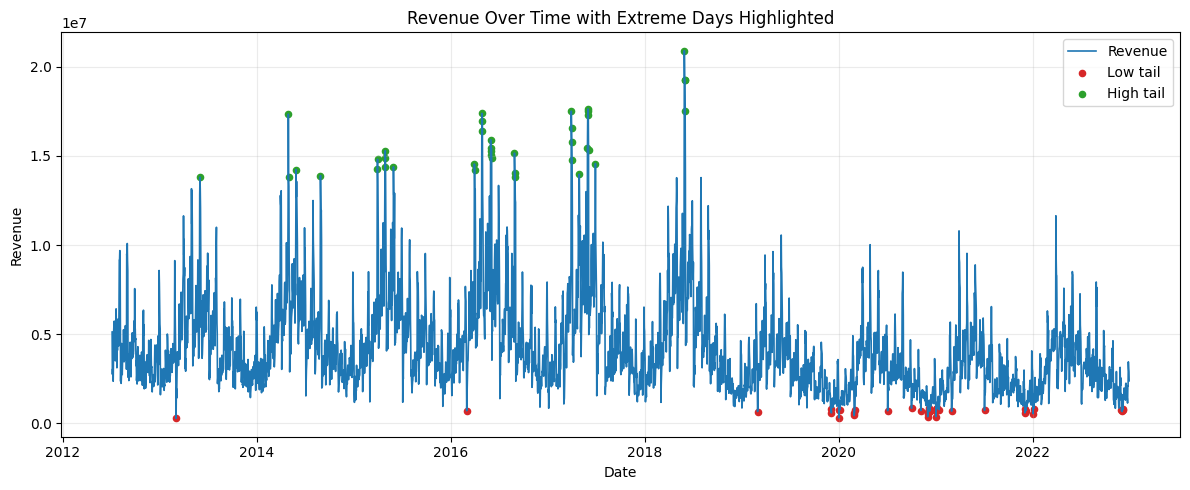

In [8]:
extreme_preview = pd.DataFrame()

if not daily_revenue.empty:
    ext = daily_revenue.copy()
    ext["year"] = ext["date"].dt.year
    ext["month"] = ext["date"].dt.month
    ext["day_of_week"] = ext["date"].dt.day_name()
    ext["Revenue_percentile"] = ext["Revenue"].rank(pct=True, method="average")
    low_cut = ext["Revenue"].quantile(0.01)
    high_cut = ext["Revenue"].quantile(0.99)
    ext["is_low_revenue_day"] = ext["Revenue"] <= low_cut
    ext["is_high_revenue_day"] = ext["Revenue"] >= high_cut

    lowest_days = ext.sort_values("Revenue", ascending=True).head(10)
    highest_days = ext.sort_values("Revenue", ascending=False).head(10)
    display(lowest_days[["date", "Revenue", "year", "month", "day_of_week", "Revenue_percentile"]])
    display(highest_days[["date", "Revenue", "year", "month", "day_of_week", "Revenue_percentile"]])

    if ext["Revenue"].eq(0).any():
        print(f"Zero-Revenue days: {int(ext['Revenue'].eq(0).sum())}")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ext["date"], ext["Revenue"], color="tab:blue", lw=1.2, label="Revenue")
    ax.scatter(ext.loc[ext["is_low_revenue_day"], "date"], ext.loc[ext["is_low_revenue_day"], "Revenue"], color="tab:red", s=20, label="Low tail")
    ax.scatter(ext.loc[ext["is_high_revenue_day"], "date"], ext.loc[ext["is_high_revenue_day"], "Revenue"], color="tab:green", s=20, label="High tail")
    ax.set_title("Revenue Over Time with Extreme Days Highlighted")
    ax.set_xlabel("Date")
    ax.set_ylabel("Revenue")
    ax.legend()
    plt.tight_layout()
    plt.show()

    extreme_preview = ext[["date", "Revenue", "Revenue_percentile", "is_low_revenue_day", "is_high_revenue_day"]].head(20)

## 9. Distribution by Year and Month

Check whether target skewness, spread, or high-end volatility changes across years and seasonally across months.

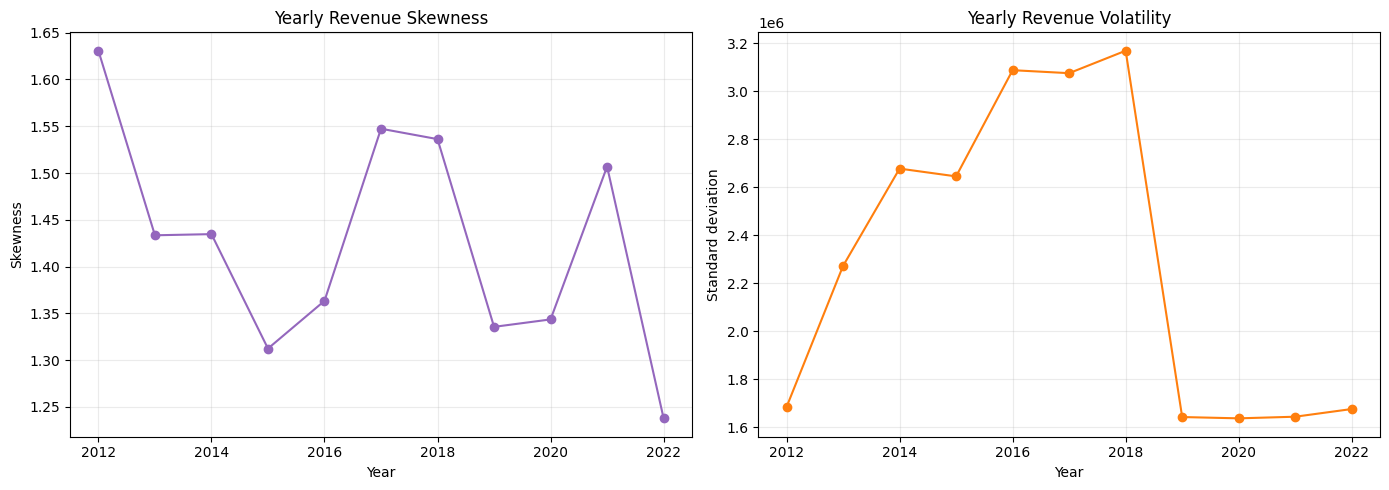

In [9]:
if not yearly_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(yearly_summary["year"], yearly_summary["skewness"], marker="o", color="tab:purple")
    axes[0].set_title("Yearly Revenue Skewness")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Skewness")
    axes[1].plot(yearly_summary["year"], yearly_summary["std_Revenue"], marker="o", color="tab:orange")
    axes[1].set_title("Yearly Revenue Volatility")
    axes[1].set_xlabel("Year")
    axes[1].set_ylabel("Standard deviation")
    plt.tight_layout()
    plt.show()

## 10. Model Implications: Raw Target vs Log-Transformed Target

Possible modeling implications:

- Raw Revenue preserves the original business scale and direct interpretability.
- `log1p(Revenue)` can reduce skewness and weaken the influence of extreme high-Revenue days.
- `log1p` is often more helpful for models sensitive to target magnitude and variance instability.
- Predictions from a log-target model must be converted back with `expm1`.
- Final model evaluation should still be computed on the original Revenue scale.
- Zero Revenue is fine for `log1p`, but Revenue `<= -1` requires special handling.
- The final target choice should be validated with cross-validation rather than visual inspection alone.

## 11. Target Variant Preview

Display a compact preview of raw Revenue, transformed Revenue, percentile rank, and simple tail flags.

In [10]:
if not extreme_preview.empty:
    preview = daily_revenue.copy()
    preview["log1p_Revenue"] = np.where(preview["Revenue"] > -1, np.log1p(preview["Revenue"]), np.nan)
    preview["Revenue_percentile"] = preview["Revenue"].rank(pct=True, method="average")
    low_cut = preview["Revenue"].quantile(0.01)
    high_cut = preview["Revenue"].quantile(0.99)
    preview["is_low_revenue_day"] = preview["Revenue"] <= low_cut
    preview["is_high_revenue_day"] = preview["Revenue"] >= high_cut
    display(preview[["date", "Revenue", "log1p_Revenue", "Revenue_percentile", "is_low_revenue_day", "is_high_revenue_day"]].head(20))

,date,Revenue,log1p_Revenue,Revenue_percentile,is_low_revenue_day,is_high_revenue_day
0,2012-07-04,"5,123,547.9400",15.4494,0.7237,False,False
1,2012-07-05,"2,751,773.4500",14.8278,0.3089,False,False
2,2012-07-06,"3,054,029.4200",14.9320,0.3744,False,False
3,2012-07-07,"2,667,930.9400",14.7968,0.2945,False,False
4,2012-07-08,"2,360,851.9000",14.6745,0.2244,False,False
5,2012-07-09,"3,548,386.4600",15.0820,0.4808,False,False
6,2012-07-10,"5,234,938.6200",15.4709,0.7368,False,False
7,2012-07-11,"5,582,884.7800",15.5352,0.7678,False,False
8,2012-07-12,"5,734,632.0200",15.5620,0.7840,False,False
9,2012-07-13,"5,309,511.7100",15.4850,0.7454,False,False


## 12. Key Observations and Warnings

Summarize skewness, tail behavior, yearly variance, log-transform usefulness, and target-design implications.

In [11]:
summary_lines = ["KEY OBSERVATIONS AND WARNINGS"]

if not daily_revenue.empty:
    rev = daily_revenue["Revenue"].dropna()
    raw_skew = rev.skew()
    neg_days = int(rev.lt(0).sum())
    zero_days = int(rev.eq(0).sum())
    high_days = int(rev.ge(rev.quantile(0.99)).sum())
    low_days = int(rev.le(rev.quantile(0.01)).sum())
    summary_lines.append(f"- Revenue is {'right-skewed' if raw_skew > 0.5 else 'not strongly skewed'} with skewness {raw_skew:.4f}.")
    summary_lines.append(f"- Raw Revenue has {high_days} extreme high days and {low_days} extreme low days under 1% tail thresholds.")

    valid_log = np.where(rev > -1, np.log1p(rev), np.nan)
    log_skew = pd.Series(valid_log).dropna().skew()
    summary_lines.append(f"- log1p(Revenue) changes skewness from {raw_skew:.4f} to {log_skew:.4f}.")

    if not yearly_summary.empty:
        widest_year = yearly_summary.sort_values("std_Revenue", ascending=False).iloc[0]
        summary_lines.append(f"- Revenue variance changes by year; the widest spread is in {int(widest_year['year'])} with std {widest_year['std_Revenue']:,.2f}.")

    if zero_days or neg_days:
        summary_lines.append(f"- Zero or negative Revenue needs handling: zero days = {zero_days}, negative days = {neg_days}. log1p is invalid for Revenue <= -1.")
    else:
        summary_lines.append("- Zero or negative Revenue values do not materially constrain log1p in this dataset.")

    summary_lines.append("- Recommended target modeling options: raw Revenue, and log1p(Revenue) with expm1 inverse transformation.")
    summary_lines.append("- Final target choice should be validated with cross-validation on the original Revenue scale, not by distribution plots alone.")
else:
    summary_lines.append("- Revenue could not be prepared, so target-distribution conclusions are unavailable.")

print("\n".join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Revenue is right-skewed with skewness 1.6700.
- Raw Revenue has 39 extreme high days and 39 extreme low days under 1% tail thresholds.
- log1p(Revenue) changes skewness from 1.6700 to -0.1594.
- Revenue variance changes by year; the widest spread is in 2018 with std 3,168,626.26.
- Zero or negative Revenue values do not materially constrain log1p in this dataset.
- Recommended target modeling options: raw Revenue, and log1p(Revenue) with expm1 inverse transformation.
- Final target choice should be validated with cross-validation on the original Revenue scale, not by distribution plots alone.
